# **Discretization**

It is the process of transformering continuous variable by creating a set of contiguous interval that span the range of the variable values.It is also called binning where bin is an alternative  name of the intervals

**Why use Discretization:**
1. To handle Outliers
2. To improve the value spread

**Type of Discretization:-**
1. Supervised :- Decision Tree binning
2. UnSupervised
    1. Equal width(uniform)
    2. Equal frequency(quantize)
    3. Kmean binning
3. Custom Binning

 **Equal width / Uniform Binning**

 to handle outliers and no change in spreading of data

**Equal Frequency**

To handle outliers as well as value spread equally

**Kmean Binning**

Ye cluster form krke ke deta h

aur ye tab ye use kiya jata h jab data cluster me faila ho

Encoding the discretized variable

Sklearn lib = KBmsDiscretized

isme teen param hote h

pahala bins=?

dusara strategy jisme teen hote h uniform quantile and kmean

tisara encoding

In [ ]:
import numpy as np
import pandas  as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [ ]:
df=pd.read_csv("/content/train (1).csv",usecols=['Age','Fare','Survived'])

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(714, 3)

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
x=df.drop("Survived",axis=1)
y=df.iloc[:,0]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
clf=DecisionTreeClassifier()
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
accuracy_score(y_test,y_pred)

0.6293706293706294

In [ ]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

np.float64(0.6331181533646322)

In [ ]:
Kbin_age=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
Kbin_fare=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [ ]:
trf=ColumnTransformer([
    ('first',Kbin_age,[0]),
    ('Second',Kbin_fare,[1])
])

In [ ]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

In [ ]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [ ]:
outputs=pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:,0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_trf[:,1]
})

In [ ]:
outputs['age_labels']=pd.cut(x=x_train['Age'],bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
outputs['fare_labels']=pd.cut(x=x_train['Fare'],bins=trf.named_transformers_['Second'].bin_edges_[0].tolist())

In [ ]:
outputs.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
456,65.0,14.0,26.5500,10.0,"(54.0, 80.0]","(26.0, 26.55]"
733,23.0,5.0,13.0000,6.0,"(21.0, 23.0]","(10.5, 13.0]"
8,27.0,6.0,11.1333,5.0,"(25.0, 28.0]","(10.5, 13.0]"
16,2.0,0.0,29.1250,10.0,"(0.42, 6.0]","(26.55, 31.275]"
579,32.0,9.0,7.9250,3.0,"(30.0, 32.0]","(7.896, 8.158]"


In [ ]:
clf=DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
y_pred2=clf.predict(x_test_trf)
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [ ]:
x_trf=trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(),x_trf,y,cv=10,scoring='accuracy'))

np.float64(0.6723004694835681)

In [ ]:
def discretize (bins,strategy):
  Kbin_age=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
  Kbin_fare=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

  trf=ColumnTransformer([
    ('first',Kbin_age,[0]),
    ('Second',Kbin_fare,[1])
  ])

  x_trf=trf.fit_transform(x)
  print(np.mean(cross_val_score(DecisionTreeClassifier(),x_trf,y,cv=10,scoring='accuracy')))

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  plt.hist(x['Age'])
  plt.title("Before")

  plt.subplot(122)
  plt.hist(x_trf[:,0],color='red')
  plt.title("After")

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  plt.hist(x['Fare'])
  plt.title("Before")

  plt.subplot(122)
  plt.hist(x_trf[:,1],color='red')
  plt.title("After")

  plt.show()

0.682140062597809


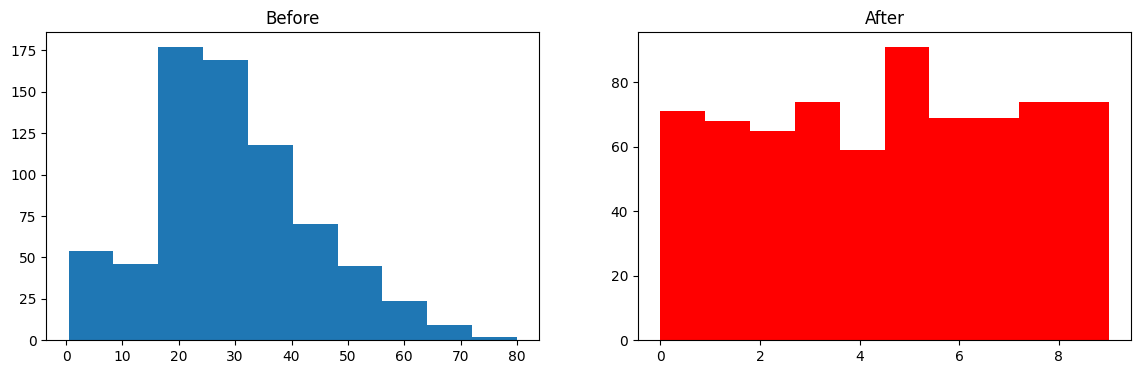

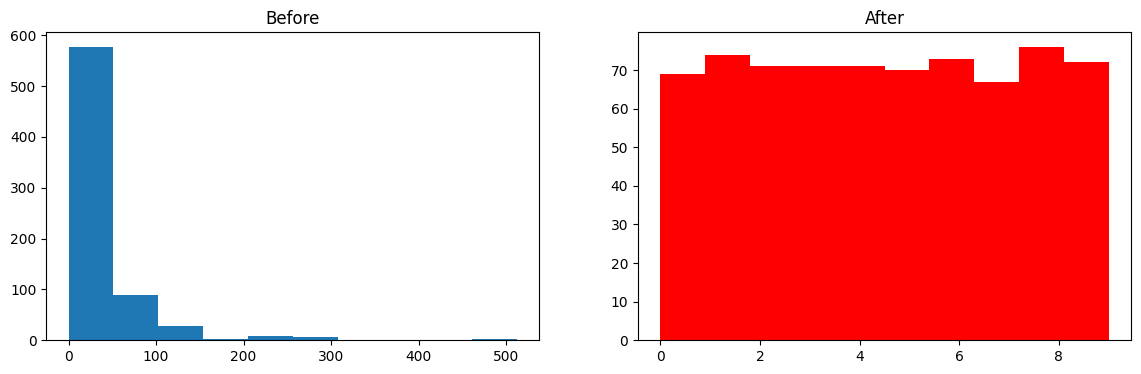

In [ ]:
discretize(10,'quantile')

# **Binarization**

it converts into binary codes either 0 or 1

not more use

used in image processing